# Empirical Analysis of European Union Unemployment Dynamics: A Macroeconomic Framework

## 1. Theoretical Note on the Unemployment Rate

The Unemployment Rate constitutes a fundamental, albeit lagging, macroeconomic indicator representing the proportion of the active labor force that is currently jobless, available for work, and actively seeking employment. Formally, it measures the underutilization of labor supply within a defined sovereign jurisdiction.

From a labor economics perspective, the active labor force is strictly the sum of employed and unemployed individuals. The unemployment rate is mathematically codified via the following ratio:

$u = \frac{U}{L} = \frac{U}{E + U}$

Where:
* **$u$**: Unemployment Rate.
* **$U$**: Number of Unemployed individuals.
* **$L$**: Active Labor Force.
* **$E$**: Number of Employed individuals.

### Typologies of Unemployment
A rigorous macroeconomic analysis necessitates the distinction between various structural forms of unemployment:
* **Frictional Unemployment:** Temporary transitional joblessness occurring as workers search for or transition between employment opportunities.
* **Structural Unemployment:** Arises from deep-seated technological shifts or spatial mismatches between labor supply skills and employer demand.
* **Cyclical Unemployment:** Driven by deviations in aggregate demand over the business cycle; it expands during recessions and contracts during macroeconomic expansions.

### Macroeconomic Significance
The unemployment rate serves as a critical diagnostic variable for monetary policy transmission. It operates centrally within the Phillips Curve framework, mapping the empirical inverse trade-off between inflation and unemployment. Furthermore, central banks closely monitor the Non-Accelerating Inflation Rate of Unemployment (NAIRU) to calibrate interest rates without triggering wage-price spirals. Through Okun's Law, empirical deviations in the unemployment rate are directly linked to aggregate output gaps relative to potential GDP.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

%load_ext sql
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [2]:
%%sql
INSTALL httpfs;
LOAD httpfs;

Running query in 'duckdb:///:memory:'

Success


In [3]:
%%sql processed_unemployment <<
WITH eurostat_raw AS (
        -- Querying the Eurostat SDMX API for annual unemployment rates (% of active population)
        -- Dimensions: Frequency (A), Age (Y15-74), Unit (PC_ACT), Sex (M, F, T), Geo (DE, FR, IT, ES)
        SELECT 
            CAST(TIME_PERIOD AS INTEGER) AS fiscal_year,
            CASE geo
                WHEN 'DE' THEN 'Germany'
                WHEN 'FR' THEN 'France'
                WHEN 'IT' THEN 'Italy'
                WHEN 'ES' THEN 'Spain'
            END AS sovereign_state,
            sex AS demographic_cohort,
            CAST(OBS_VALUE AS FLOAT) AS unemployment_rate
        FROM read_csv_auto('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/une_rt_a/A.Y15-74.PC_ACT.M+F+T.DE+FR+IT+ES?format=SDMX-CSV')
        WHERE OBS_VALUE IS NOT NULL
    ),
    demographic_pivot AS (
        -- Pivoting the dataset to isolate systemic disparities between male and female labor cohorts
        PIVOT eurostat_raw
        ON demographic_cohort
        USING FIRST(unemployment_rate)
        GROUP BY fiscal_year, sovereign_state
    )
    SELECT 
        fiscal_year,
        sovereign_state,
        T AS aggregate_unemployment_rate,
        M AS male_unemployment_rate,
        F AS female_unemployment_rate
    FROM demographic_pivot
    ORDER BY fiscal_year DESC, sovereign_state;

Running query in 'duckdb:///:memory:'

## 2. Empirical Visualization of Trajectories

Having extracted the Unemployment Rate series (expressed as a percentage of the active population), we proceed to visually inspect the secular trends and cyclical labor market fluctuations across primary Eurozone economies. This visualization empirically exposes labor market rigidities, historical structural shocks (such as the 2012 European Sovereign Debt Crisis and the exogenous 2020 COVID-19 pandemic shock), and the divergent absorption capacities across the selected sovereign states.

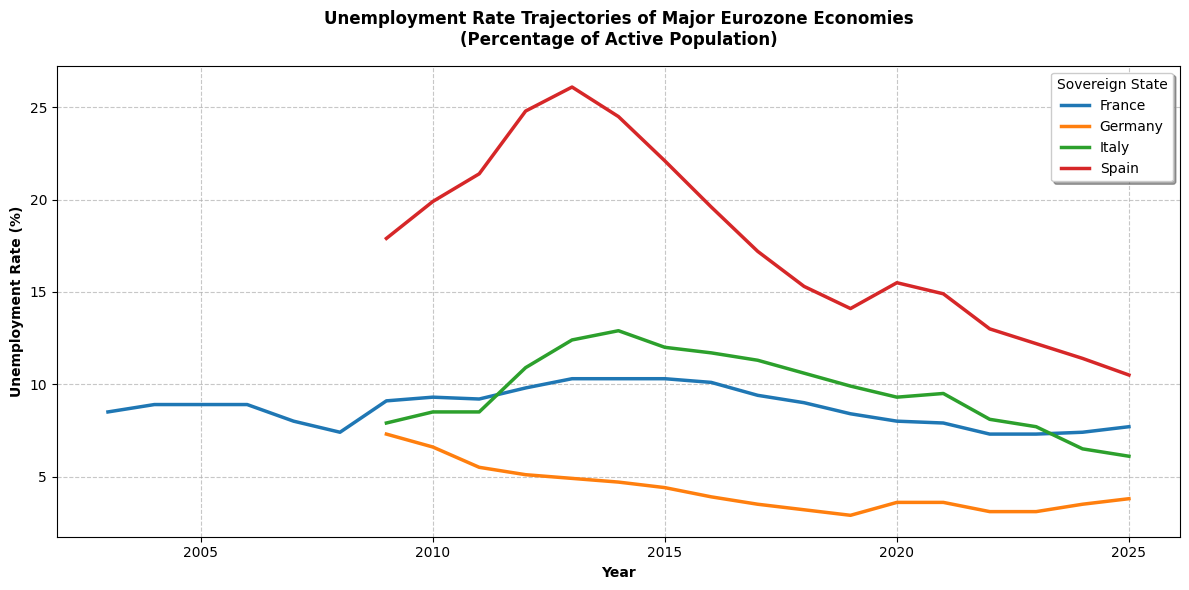

In [6]:
# Data Visualization: Time Series

# 1. Convert the SQL result into a Pandas DataFrame
df = processed_unemployment.DataFrame()

# 2. Pivot the DataFrame to index by 'year' and map columns to countries for the Total Rate
df_ts = df.pivot(index='fiscal_year', columns='sovereign_state', values='aggregate_unemployment_rate')

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the time series trajectory for each sovereign state
for country in df_ts.columns:
    ax.plot(df_ts.index, df_ts[country], linewidth=2.5, label=country)

# Formatting the axes and title for academic presentation
ax.set_title('Unemployment Rate Trajectories of Major Eurozone Economies\n(Percentage of Active Population)', fontweight='bold', pad=15)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)', fontweight='bold')

# Enhance grid readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend(title='Sovereign State', loc='upper right', frameon=True, shadow=True)

# Tight layout for export readiness
plt.tight_layout()
plt.show()

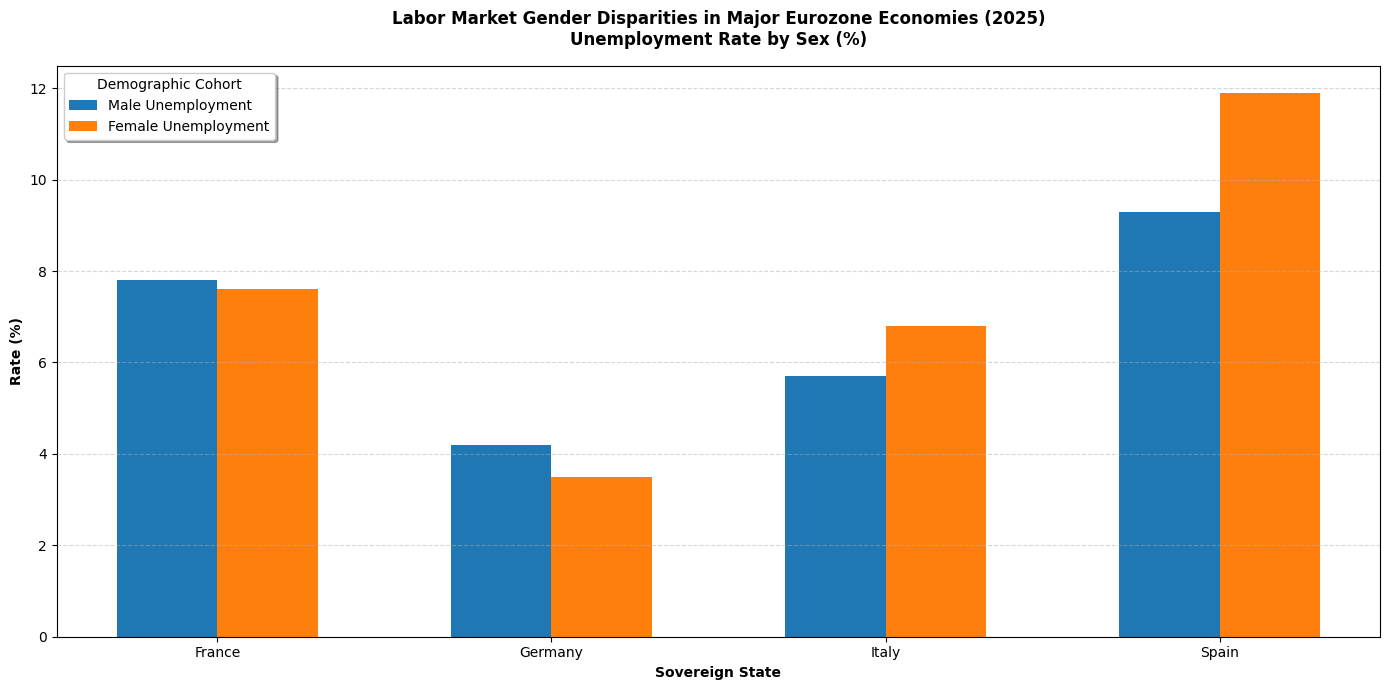

In [9]:
import numpy as np

# 1. Identify the most recent available year for cross-sectional analysis
current_year = df['fiscal_year'].max()
df_current = df[df['fiscal_year'] == current_year].set_index('sovereign_state')

# 2. Prepare data structures for a grouped demographic bar chart
countries = df_current.index.tolist()
components = ['male_unemployment_rate', 'female_unemployment_rate']
labels = ['Male Unemployment', 'Female Unemployment']

x = np.arange(len(countries))  # Group positioning
width = 0.3  # Individual bar width

fig, ax = plt.subplots(figsize=(14, 7))

# Plot a bar for each demographic cohort
for i, comp in enumerate(components):
    ax.bar(x + (i * width) - (width / 2), df_current[comp], width, label=labels[i])

# Academic and aesthetic formatting
ax.set_title(f'Labor Market Gender Disparities in Major Eurozone Economies ({current_year})\nUnemployment Rate by Sex (%)', fontweight='bold', pad=15)
ax.set_xlabel('Sovereign State', fontweight='bold')
ax.set_ylabel('Rate (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(countries)

ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.legend(title='Demographic Cohort', frameon=True, shadow=True)

plt.tight_layout()
plt.show()